In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 10: 고객별 구매 카테고리 다양성(구매한 고유 카테고리 수)을 분석하세요.
# 비즈니스 목적: 고객의 쇼핑 스타일을 파악하고, 다양한 카테고리를 구매하는 고객에게는 신규 카테고리 상품을, 
# 특정 카테고리만 구매하는 고객에게는 해당 카테고리의 심화 상품을 추천하는 등 개인화 마케팅에 활용합니다.

###### 출력 결과를 보고 코딩하세요
```text 
고객별 구매 카테고리 다양성 (상위 10명):
customer_id
C0051    7
C1510    7
C0616    7
C0617    7
C0625    7
C1859    7
C0779    7
C0412    7
C0863    7
C0253    7
Name: category, dtype: int64
```
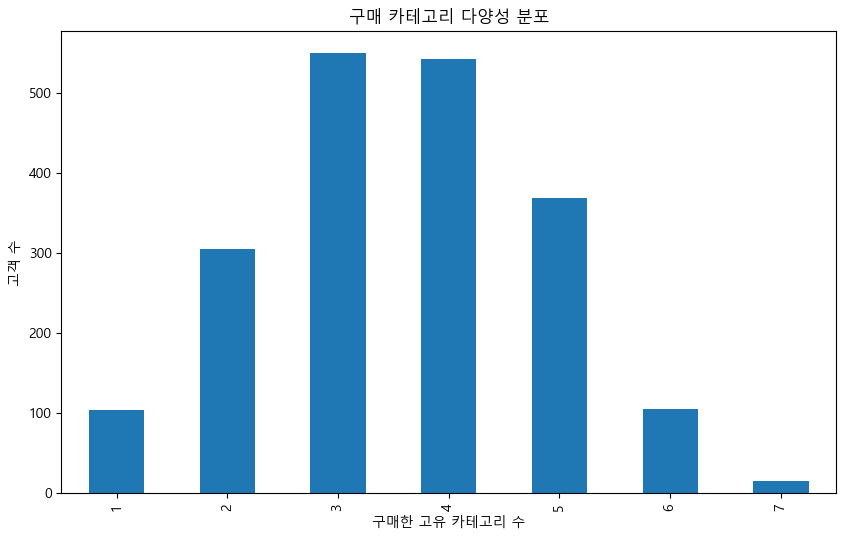

In [3]:
# 문제 10: 고객별 구매 카테고리 다양성(구매한 고유 카테고리 수)을 분석하세요.
# quest_cols = ['customer_id', 'category']
result_quest2A = (
  df[['customer_id', 'category']].copy()
  .groupby('customer_id')['category'] # 고객별 구매 카테고리별로 그룹핑
  .nunique() # 구매 카테고리 중복제거하고 count
  .sort_values(ascending=False) # 구매 카테고리수만큼 내림차순
)

print('고객별 구매 카테고리 다양성 (상위 10명):')
result_quest2A.head(10)

고객별 구매 카테고리 다양성 (상위 10명):


customer_id
C0051    7
C1510    7
C0616    7
C0617    7
C0625    7
C1859    7
C0779    7
C0412    7
C0863    7
C0253    7
Name: category, dtype: int64

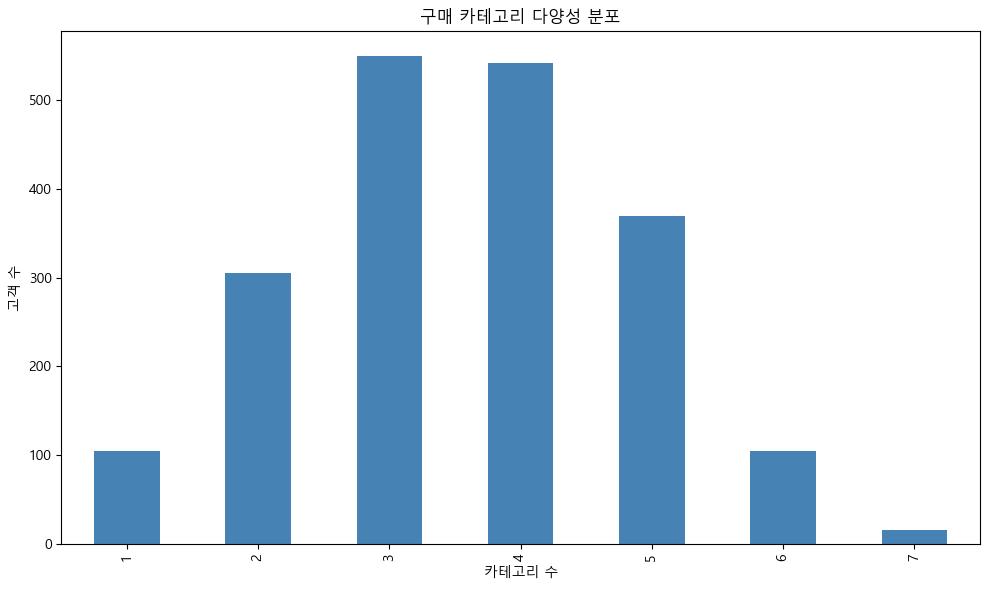

In [ ]:
# 시각화
plt.figure(figsize=(10, 6))
result_quest2A.value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('구매한 카테고리 수')
plt.ylabel('고객 수')
plt.title('구매 카테고리 다양성 분포')
plt.tight_layout()
plt.show()